In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
!python --version

Python 3.12.13


In [3]:
pd.set_option("display.max_rows", 100)

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import os

dataset_path = '/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/WooJung/test_set'

if os.path.exists(dataset_path):
    print(f"Files in '{dataset_path}' starting with 'Talk':")
    found_files = [f for f in os.listdir(dataset_path) if f.startswith('Talk') & f.endswith("csv")]
    if found_files:
        for f in found_files:
            print(f)
    else:
        print("No files found starting with 'Talk'.")
else:
    print(f"Directory '{dataset_path}' not found. Please ensure Google Drive is mounted and the path is correct.")

Files in '/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/WooJung/test_set' starting with 'Talk':
TalkFile_사랑양_glucose_canine3.csv.csv
TalkFile_현수김_glucose_canine6.csv.csv


There are two dogs in this dataset:
* canine3: Sarang
* canine 6: Hyeon-Soo

In [33]:
file1 = os.path.join(dataset_path, found_files[0])
file1_pd = pd.read_csv(file1, header = 2, usecols = [0, 1, 2, 3, 4, 5])
file1_pd.head()

,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL
0,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 20:11,0,364.0,NaN
1,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 20:26,0,288.0,NaN
2,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 20:41,0,223.0,NaN
3,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 20:56,0,181.0,NaN
4,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 21:10,0,162.0,NaN


In [45]:

dfs = []


for filename in found_files:
    full_file_path = os.path.join(dataset_path, filename)

    # Extract identifier to be 'canine1', 'canine2', etc.
    identifier = filename.split('_glucose_')[1].split('.')[0]

    # Read the file into a DataFrame
    df = pd.read_csv(full_file_path, header = 2, usecols = [0, 1, 2, 3, 4, 5])

    # Add a new column 'ID' (changed name from file_identifier)
    df['ID'] = identifier


    # Append the processed DataFrame to the list
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# sort by ID
combined_df = combined_df.sort_values(by = ["ID", "Device Timestamp"])

print(f"Shape of the combined DataFrame: {combined_df.shape}")
# printing everything because we only have 6 rows
print("Combined DataFrame:")
display(combined_df.groupby("ID").first())

Shape of the combined DataFrame: (19538, 7)
Combined DataFrame:


,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mg/dL,Scan Glucose mg/dL
ID,,,,,,
canine3,FreeStyle LibreLink,A8E9D4EE-4BB8-42B4-9A0E-37AF363D55C0,2026-02-10 19:08,6,364.0,119.0
canine6,FreeStyle LibreLink,80421225-a52b-469b-86fb-2f05c7612945,2024-01-11 14:46,6,447.0,441.0


In [35]:
glucose_counts = combined_df.groupby(["ID", "Record Type"])[['Historic Glucose mg/dL', 'Scan Glucose mg/dL']].count()
display(glucose_counts)

Historic Glucose mg/dL  Scan Glucose mg/dL
ID      Record Type                                            
canine3 0                               440                   0
        1                                 0                  26
        6                                 0                   0
canine6 0                             12082                   0
        1                                 0                5288
        5                                 0                   0
        6                                 0                   0

In [58]:
# get observations from record type 0 or 1 (because all other observations are NA for glucose levels)
combined_df = combined_df[combined_df["Record Type"].isin([0, 1])].copy()

# get combined glucose levels
combined_df["glucose"] = combined_df["Historic Glucose mg/dL"].fillna(combined_df["Scan Glucose mg/dL"])

# reformatting timestamp
combined_df["timestamp"] = pd.to_datetime(combined_df["Device Timestamp"])

# sort by ID and timestamp
combined_df = combined_df.sort_values(["ID", "timestamp"])

combined_df = combined_df[["ID", "timestamp", "glucose"]]

# adding glucose category
combined_df["glucose_category"] = np.select(

    # set ranges
    [
        combined_df["glucose"] < 65,
        combined_df["glucose"] > 250
    ],
    # set categories
    [
        "hypoglycemia",
        "hyperglycemia"
    ],
    # other cases
    default = "normal"
)

# now adding normal_ranges
combined_df["normal_range"] = combined_df["glucose_category"] == "normal"


# now check shape, first rows, dtype
print(f"Shape of the combined DataFrame: {combined_df.shape}")
print("Combined DataFrame:")

# displaying first two rows to check for time order
display(combined_df.groupby("ID").head(2))

display(combined_df.dtypes)

Shape of the combined DataFrame: (17836, 5)
Combined DataFrame:


,ID,timestamp,glucose,glucose_category,normal_range
0,canine3,2026-02-10 20:11:00,364.0,hyperglycemia,False
1,canine3,2026-02-10 20:26:00,288.0,hyperglycemia,False
3664,canine6,2025-09-20 14:28:00,447.0,hyperglycemia,False
13887,canine6,2025-09-20 14:31:00,441.0,hyperglycemia,False


,0
ID,object
timestamp,datetime64[ns]
glucose,float64
glucose_category,object
normal_range,bool


### Removing Duplicates

Total number of duplicates: 414
----------------------------------------------------------------------------------------------------------------------------------------------------------------


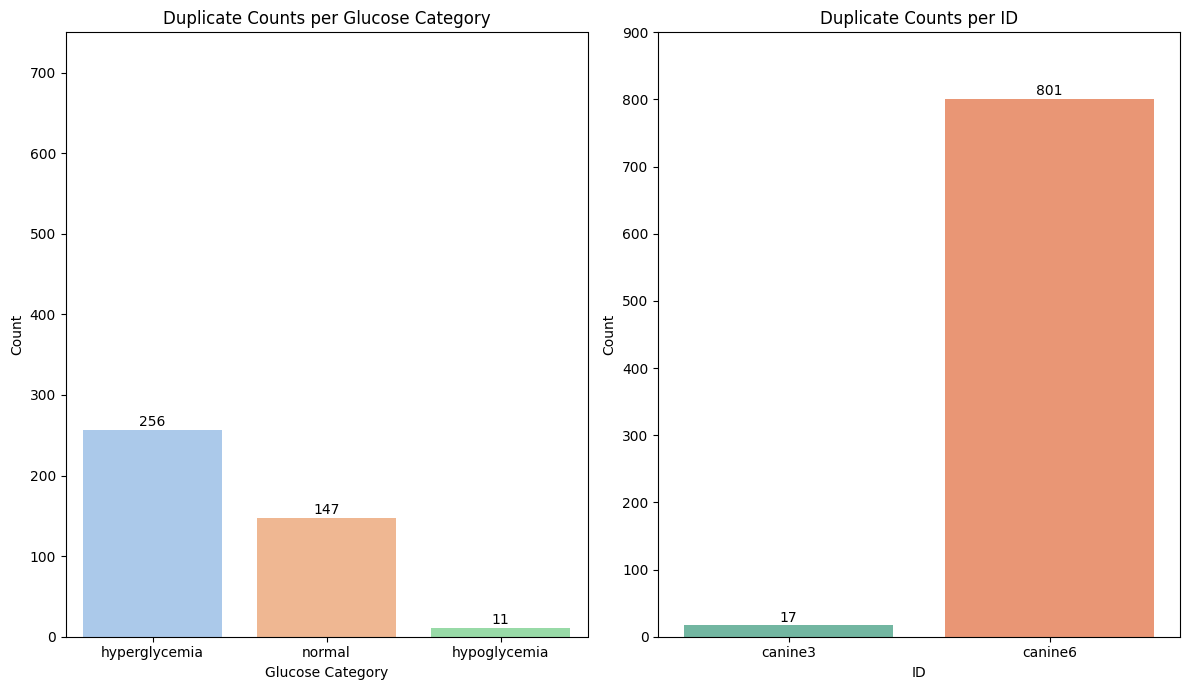

In [61]:
duplicate_counts = combined_df[combined_df.duplicated(subset = ["ID", "timestamp"])]["glucose_category"].value_counts()

duplicate_by_ID = combined_df[combined_df.duplicated(subset = ["ID", "timestamp"], keep = False)].groupby("ID").size()

print(f"Total number of duplicates: {duplicate_counts.sum()}")

print("--"*80)

fig, axes = plt.subplots(1, 2, figsize = (12, 7))

# duplicates by glucose category
ax1 = sns.barplot(
    ax = axes[0],
    data = duplicate_counts.reset_index(name = "count"),
    x = "glucose_category",
    y = "count",
    hue = "glucose_category",
    palette = "pastel"
)

for p in ax1.patches:
  height = p.get_height()
  ax1.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
)

ax1.set_title("Duplicate Counts per Glucose Category")
ax1.set_xlabel("Glucose Category")
ax1.set_ylabel("Count")
ax1.set_ylim(0, 750)


ax2 = sns.barplot(
    ax = axes[1],
    data = duplicate_by_ID.reset_index(name = "count"),
    x = "ID",
    y = "count",
    hue = "ID",
    palette = "Set2"
)

for p in ax2.patches:
  height = p.get_height()
  ax2.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
)

ax2.set_title("Duplicate Counts per ID")
ax2.set_xlabel("ID")
ax2.set_ylabel("Count")
ax2.set_ylim(0, 900)

plt.tight_layout()

In [62]:
dup_removed = (
    combined_df
    # sort time and glucose levels
    .sort_values(["ID", "timestamp", "glucose"])

    # get only the first observation such that we are getting the lowest value for glucose level with the same timestamp
    .drop_duplicates(subset = ["ID", "timestamp"], keep = "first")
    .reset_index(drop = True)
)

In [63]:
# check that there are no duplicates now
dup_removed[dup_removed.duplicated(subset = ["ID", "timestamp"])]

,ID,timestamp,glucose,glucose_category,normal_range


In [64]:
print(f"Shape of dataframe before removing duplicates: {combined_df.shape}")
print(f"Shape of dataframe after removing duplicates: {dup_removed.shape}")

Shape of dataframe before removing duplicates: (17836, 5)
Shape of dataframe after removing duplicates: (17422, 5)


### Data Split

In [67]:
gap_df = dup_removed.copy()
gap_df["gap_min"] = (
    gap_df
    .groupby("ID")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

gap_count = gap_df.groupby("ID")["gap_min"].agg(["min", "max", "median", "std", "count"]).reset_index()


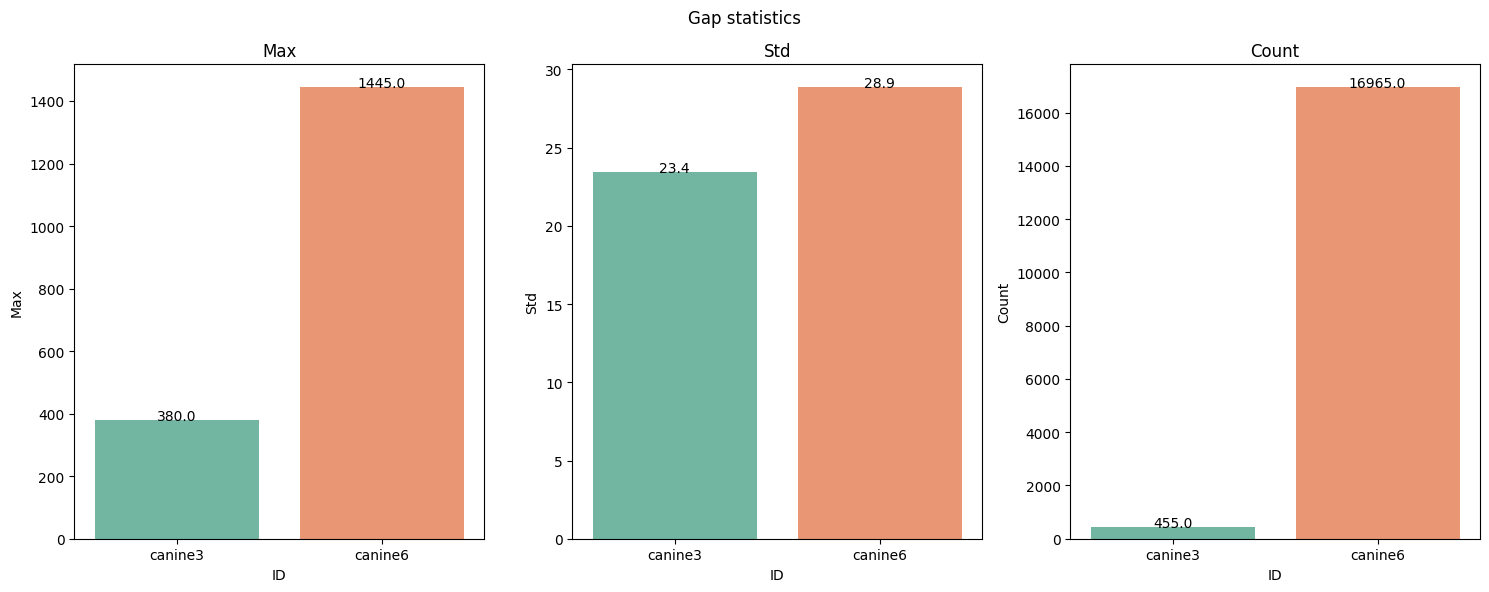

In [73]:
stats = ["max", "std", "count"]

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 6), sharey = False)

axes = axes.flatten()

for ax, stat in zip(axes, stats):
  sns.barplot(
      data = gap_count,
      x = "ID",
      y = stat,
      ax = ax,
      hue = "ID",
      palette = "Set2"
  )
  # labeling
  for p in ax.patches:
    height = p.get_height()
    ax.text(
      x = p.get_x() + p.get_width()/2,
      y = height,
      s = f"{height:.1f}",
      ha = "center"
      )

  ax.set_title(stat.capitalize())
  ax.set_xlabel("ID")
  ax.set_ylabel(stat.capitalize())

plt.tight_layout(rect = [0, 0, 1, .95])
plt.suptitle("Gap statistics")
plt.show()


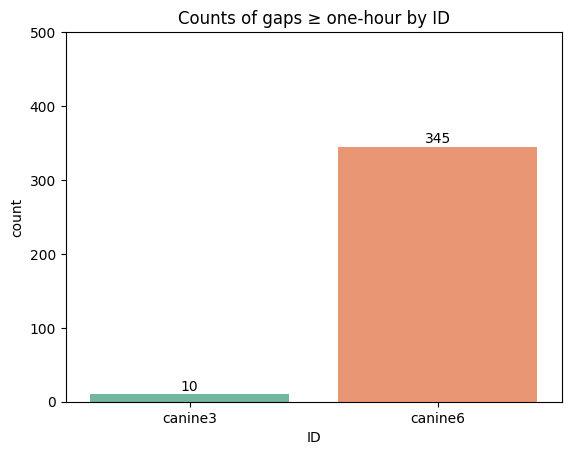

In [76]:
large_gap = gap_df[gap_df["gap_min"] >= 60].copy()
large_df = large_gap.groupby("ID").size().reset_index(name = "count")

ax = sns.barplot(
    data = large_df,
    x = "ID",
    y = "count",
    hue = "ID",
    palette = "Set2"
    )

for p in ax.patches:
    height = p.get_height()
    ax.text(
      x = p.get_x() + p.get_width()/2,
      y = height + 5,
      s = int(height),
      ha = "center"
      )
plt.ylim(0, 500)
plt.title("Counts of gaps ≥ one-hour by ID")
plt.show()



In [77]:
max_gap = 60

In [78]:
def add_split_flags(df, max_gap = max_gap):

  df = df.copy()

  df = df.sort_values(["ID", "timestamp"])

  # adding flags for making splits
  df["split_flag"] = (
      (df["gap_min"] >= max_gap) | (df["gap_min"].isna())
  )

  df["sub_id"] = (
      df
      .groupby("ID")["split_flag"]
      .cumsum()
      .astype(str)
      .str.zfill(3)
  )

  df["split_id"] = (
      df["ID"] + "-" + df["sub_id"]
  )

  # df = df.drop(columns = ["sub_id"])

  return df

In [79]:
gap_split = add_split_flags(gap_df, max_gap)

gap_split.groupby("ID").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
0,canine3,2026-02-10 20:11:00,364.0,hyperglycemia,False,NaN,True,001,canine3-001
1,canine3,2026-02-10 20:26:00,288.0,hyperglycemia,False,15.0,False,001,canine3-001
456,canine6,2025-09-20 14:28:00,447.0,hyperglycemia,False,NaN,True,001,canine6-001
457,canine6,2025-09-20 14:31:00,441.0,hyperglycemia,False,3.0,False,001,canine6-001


In [80]:
print(f"Number of groups: {gap_split["split_id"].nunique()}")

split_counts = gap_split.groupby("split_id")["timestamp"].agg("count").reset_index(name = "Observations")
display(split_counts.describe())

Number of groups: 357


,Observations
count,357.000000
mean,48.801120
std,67.331039
min,1.000000
25%,4.000000
50%,28.000000
75%,68.000000
max,580.000000


### Removing subgroups less than 11 observations

In [81]:
print(f"Number of Subgroups with observations less than 11: {split_counts[split_counts["Observations"] < 11]["Observations"].count()}")
print(f"Proportion of Subgroups with observations less than 11: {split_counts[split_counts["Observations"] < 11]["Observations"].count()/split_counts["Observations"].count():.2f}")
print(f"Number of Observations that belong to these subgroups: {split_counts[split_counts["Observations"] < 11]["Observations"].sum()}")
print(f"Proportion of Observations that will be removed: {split_counts[split_counts["Observations"] < 11]["Observations"].sum()/split_counts["Observations"].sum():.2f}")


Number of Subgroups with observations less than 11: 128
Proportion of Subgroups with observations less than 11: 0.36
Number of Observations that belong to these subgroups: 435
Proportion of Observations that will be removed: 0.02


In [82]:
def remove_small_subgroup(df, split_threshold):
  segment_counts = (
      df
      .groupby("split_id", sort = False)["timestamp"]
      .agg("count")
  )

  valid_segments = segment_counts[segment_counts >= split_threshold].index

  filtered_df = df[df["split_id"].isin(valid_segments)]

  return filtered_df

In [83]:
split_threshold = 11

In [84]:
filtered_df = remove_small_subgroup(gap_split, split_threshold = split_threshold)
print(f"Number of observations after filtering: {filtered_df.shape[0]}")

Number of observations after filtering: 16987


In [85]:
filtered_split = filtered_df.groupby("split_id")["timestamp"].agg("count").reset_index(name = "Observations")
print(f"Number of subgroups after filtering: {filtered_split.shape[0]}")
display(filtered_split.describe())

Number of subgroups after filtering: 229


,Observations
count,229.000000
mean,74.179039
std,72.596085
min,11.000000
25%,31.000000
50%,54.000000
75%,91.000000
max,580.000000


In [86]:
cleaned_split = add_split_flags(filtered_df, max_gap)
display(cleaned_split.groupby("ID")["split_id"].nunique())
display(cleaned_split.groupby("ID")["split_id"].tail(1))
display(cleaned_split.groupby("split_id").head(2).head(10))

,split_id
ID,
canine3,7
canine6,222


,split_id
453,canine3-007
17421,canine6-222


,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
0,canine3,2026-02-10 20:11:00,364.0,hyperglycemia,False,NaN,True,001,canine3-001
1,canine3,2026-02-10 20:26:00,288.0,hyperglycemia,False,15.0,False,001,canine3-001
94,canine3,2026-02-11 19:50:00,261.0,hyperglycemia,False,123.0,True,002,canine3-002
95,canine3,2026-02-11 20:05:00,240.0,normal,True,15.0,False,002,canine3-002
190,canine3,2026-02-12 22:29:00,483.0,hyperglycemia,False,139.0,True,003,canine3-003
191,canine3,2026-02-12 22:44:00,493.0,hyperglycemia,False,15.0,False,003,canine3-003
332,canine3,2026-02-14 11:56:00,500.0,hyperglycemia,False,135.0,True,004,canine3-004
333,canine3,2026-02-14 12:11:00,500.0,hyperglycemia,False,15.0,False,004,canine3-004
364,canine3,2026-02-14 22:12:00,434.0,hyperglycemia,False,75.0,True,005,canine3-005
365,canine3,2026-02-14 22:27:00,435.0,hyperglycemia,False,15.0,False,005,canine3-005


In [87]:
final_df = cleaned_split.sort_values(by=["ID", "sub_id", "timestamp"])
final_df.groupby("split_id").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
0,canine3,2026-02-10 20:11:00,364.0,hyperglycemia,False,NaN,True,001,canine3-001
1,canine3,2026-02-10 20:26:00,288.0,hyperglycemia,False,15.0,False,001,canine3-001
94,canine3,2026-02-11 19:50:00,261.0,hyperglycemia,False,123.0,True,002,canine3-002
95,canine3,2026-02-11 20:05:00,240.0,normal,True,15.0,False,002,canine3-002


In [88]:
# recalculate gap_min
final_df["gap_min"] = (
    final_df
    .groupby("split_id")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

final_df.groupby("split_id").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min,split_flag,sub_id,split_id
0,canine3,2026-02-10 20:11:00,364.0,hyperglycemia,False,NaN,True,001,canine3-001
1,canine3,2026-02-10 20:26:00,288.0,hyperglycemia,False,15.0,False,001,canine3-001
94,canine3,2026-02-11 19:50:00,261.0,hyperglycemia,False,NaN,True,002,canine3-002
95,canine3,2026-02-11 20:05:00,240.0,normal,True,15.0,False,002,canine3-002


In [89]:
# now clean up the columns that we are not going to use and reassign IDs as split_ids
final_df["ID"] = final_df["split_id"]

final_df = final_df.drop(columns = ["split_id", "split_flag", "sub_id"])

final_df.groupby("ID").head(2).head(10)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine3-001,2026-02-10 20:11:00,364.0,hyperglycemia,False,NaN
1,canine3-001,2026-02-10 20:26:00,288.0,hyperglycemia,False,15.0
94,canine3-002,2026-02-11 19:50:00,261.0,hyperglycemia,False,NaN
95,canine3-002,2026-02-11 20:05:00,240.0,normal,True,15.0
190,canine3-003,2026-02-12 22:29:00,483.0,hyperglycemia,False,NaN
191,canine3-003,2026-02-12 22:44:00,493.0,hyperglycemia,False,15.0
332,canine3-004,2026-02-14 11:56:00,500.0,hyperglycemia,False,NaN
333,canine3-004,2026-02-14 12:11:00,500.0,hyperglycemia,False,15.0
364,canine3-005,2026-02-14 22:12:00,434.0,hyperglycemia,False,NaN
365,canine3-005,2026-02-14 22:27:00,435.0,hyperglycemia,False,15.0


In [90]:
# saving to .csv file in case you want to save the file in your directory for easier loading

# Ainsley
# out_dir =

# Ci
# out_dir =

# WooJung
out_dir = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/WooJung/test_set"

final_df.to_csv(out_dir + "/final_df.csv", index = False)

print("final_df in .csv format saved in:", out_dir)

final_df in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/WooJung/test_set
